# Superseded

This notebook is the original OrthoForest / CausalForest exploration on the **pre-refactor schema** (`treatment_sample.csv`, old `governance_pc1/pc2`, where PC2 was the now-retired "democratic paradox" variable). The canonical, schema-correct heterogeneity analysis is in **`causal_effects_library.ipynb`**, which uses the new PC3-based moderators, the corrected methodology, and an OrthoForest re-validation. Kept for historical reference; results below reflect the old definitions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression

In [2]:
data = pd.read_csv("../data/cleaned/treatment_sample.csv")

In [3]:


# Confounders (W) - things that affect both treatment and outcome
W_cols = [
    'log_gdp', 'log_population',
    'years_since_tax',  
    'trade_openness',
    'natural_resource_rents_per_gdp',
    'industry_share_gdp',
    'energy_per_capita',
    'average_years_of_schooling'
]
W = data[W_cols].values if len(W_cols) > 0 else None

X_cols = [
    'governance_pc1', 'governance_pc2',
    'average_years_of_schooling',
    'fossil_pct', 'nuclear_pct', 'renewable_pct'
]
X = data[X_cols].values

In [4]:
cf_dml = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, random_state=42),  # Outcome model
    model_t=RandomForestClassifier(n_estimators=100, random_state=42), # Treatment model


    n_estimators=500,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,

    discrete_treatment=True,       # Binary treatment
    random_state=42,
    n_jobs=-1
)

In [5]:
# Check for missing values in each component


if W is not None:
    print(f"W (confounders): {pd.isna(W).sum()} missing out of {W.size}")
    W_df = pd.DataFrame(W, columns=W_cols)
    print("Missing by confounder:")
    print(W_df.isnull().sum())

print(f"X (moderators): {pd.isna(X).sum()} missing out of {X.size}")
X_df = pd.DataFrame(X, columns=X_cols)
print("Missing by moderator:")
print(X_df.isnull().sum())

W (confounders): 518 missing out of 30944
Missing by confounder:
log_gdp                             0
log_population                      0
years_since_tax                     0
trade_openness                    359
natural_resource_rents_per_gdp     49
industry_share_gdp                  0
energy_per_capita                   1
average_years_of_schooling        109
dtype: int64
X (moderators): 133 missing out of 23208
Missing by moderator:
governance_pc1                 12
governance_pc2                 12
average_years_of_schooling    109
fossil_pct                      0
nuclear_pct                     0
renewable_pct                   0
dtype: int64


In [6]:
df_work = data.copy()
governance_complete = ~(df_work['governance_pc1'].isna() | df_work['governance_pc2'].isna())
df_work = df_work[governance_complete]

In [7]:
education_missing = df_work['average_years_of_schooling'].isna()
if education_missing.sum() > 0:
    # Impute education data.
    education_predictors = ['log_gdp', 'governance_pc1', 'governance_pc2']
    education_complete = df_work[~education_missing]
    educ_model = LinearRegression()
    educ_model.fit(
        education_complete[education_predictors], 
        education_complete['average_years_of_schooling']
    )
    predicted_education = educ_model.predict(
        df_work.loc[education_missing, education_predictors]
    )
    df_work.loc[education_missing, 'average_years_of_schooling'] = predicted_education
    print(f"Education R^2: {educ_model.score(education_complete[education_predictors], education_complete['average_years_of_schooling']):.3f}")

Education R^2: 0.481


In [8]:
for var in ['trade_openness', 'natural_resource_rents_per_gdp', 'energy_per_capita']:
    missing_mask = df_work[var].isna()
    if missing_mask.sum() > 0:
        
        # Use country-specific median where available
        country_medians = df_work.groupby('country')[var].median()
        
        for country in df_work.loc[missing_mask, 'country'].unique():
            country_mask = (df_work['country'] == country) & missing_mask
            if country in country_medians and not pd.isna(country_medians[country]):
                df_work.loc[country_mask, var] = country_medians[country]
            else:
                # Use global median as fallback
                global_median = df_work[var].median()
                df_work.loc[country_mask, var] = global_median


In [9]:
print("Step 4: Final cleanup...")
remaining_vars = W_cols + X_cols
remaining_missing = df_work[remaining_vars].isna().sum().sum()

if remaining_missing > 0:
    print(f"Final KNN imputation for {remaining_missing} remaining missing values...")
    final_imputer = KNNImputer(n_neighbors=5)
    df_work[remaining_vars] = final_imputer.fit_transform(df_work[remaining_vars])

Step 4: Final cleanup...


In [10]:
Y_clean = df_work['co2_per_capita_future_trend'].values
T_clean = df_work['post_carbon_tax'].values
X_clean = df_work[X_cols].values
W_clean = df_work[W_cols].values

In [11]:
# NOTE: Previous spec used min_samples_leaf=10 and max_depth=None, which produced
# CATE estimates ranging -10.1 to +7.2 for never-treated countries — clear overfitting.
# With ~491 treated obs, min_samples_leaf=50 is the appropriate floor.
# max_depth=4 further prevents spurious extrapolation.
cf_dml = CausalForestDML(
    model_y=RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        min_samples_leaf=30,
        random_state=42
    ),
    model_t=RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_leaf=30,
        random_state=42
    ),
    n_estimators=1000,
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=50,
    discrete_treatment=True,
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [12]:
cf_dml.fit(Y_clean, T_clean, X=X_clean, W=W_clean)
print("CausalForestDML fitted")
effects = cf_dml.effect(X_clean)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    1.9s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    1.5s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elaps

CausalForestDML fitted


[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:    0.3s
[Parallel(n_jobs=12)]: Done 1000 out of 1000 | elapsed:    0.4s finished


In [13]:
print(f"\n Summary:")
print(f"Mean effect: {effects.mean():.4f}")
print(f"Std deviation: {effects.std():.4f}")
print(f"Min effect: {effects.min():.4f}")
print(f"Max effect: {effects.max():.4f}")


 Summary:
Mean effect: 0.0003
Std deviation: 0.1575
Min effect: -0.1781
Max effect: 0.6912


In [14]:
pc1_values = X_clean[:, X_cols.index('governance_pc1')]
pc2_values = X_clean[:, X_cols.index('governance_pc2')]

pc1_corr = np.corrcoef(effects, pc1_values)[0,1]
pc2_corr = np.corrcoef(effects, pc2_values)[0,1]

print(f"PC1 correlation: {pc1_corr:.3f}")
print(f"PC2 correlation: {pc2_corr:.3f}")

PC1 correlation: 0.007
PC2 correlation: 0.156


In [15]:
# Validate no extreme CATE values remain for never-treated observations
never_treated_mask = T_clean == 0
never_treated_effects = effects[never_treated_mask]

print("CATE distribution for never-treated observations:")
print(f"  Mean: {never_treated_effects.mean():.4f}")
print(f"  Std:  {never_treated_effects.std():.4f}")
print(f"  Min:  {never_treated_effects.min():.4f}")
print(f"  Max:  {never_treated_effects.max():.4f}")
print(f"\nNever-treated obs with |CATE| > 1.0: {(np.abs(never_treated_effects) > 1.0).sum()}")

extreme_mask = np.abs(effects) > 1.0
if extreme_mask.sum() > 0:
    extreme_countries = df_work.loc[extreme_mask, 'country'].value_counts().head(10)
    print(f"\nWARNING: {extreme_mask.sum()} observations still have |CATE| > 1.0")
    print(extreme_countries)
else:
    print("\nValidation PASSED: No extreme CATE values.")

CATE distribution for never-treated observations:
  Mean: 0.0035
  Std:  0.1670
  Min:  -0.1781
  Max:  0.6912

Never-treated obs with |CATE| > 1.0: 0

Validation PASSED: No extreme CATE values.


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import os

# Propensity score overlap diagnostic
# Uses confounders (W) to predict treatment assignment
scaler = StandardScaler()
W_scaled = scaler.fit_transform(W_clean)

lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(W_scaled, T_clean)
ps_scores = lr.predict_proba(W_scaled)[:, 1]

treated_ps = ps_scores[T_clean == 1]
control_ps = ps_scores[T_clean == 0]

print(f"Treated obs: {(T_clean == 1).sum()}")
print(f"Control obs: {(T_clean == 0).sum()}")
print(f"\nPropensity score summary:")
print(f"  Treated — mean={treated_ps.mean():.3f}, min={treated_ps.min():.3f}, max={treated_ps.max():.3f}")
print(f"  Control — mean={control_ps.mean():.3f}, min={control_ps.min():.3f}, max={control_ps.max():.3f}")

# Trimming threshold (Crump et al. 2009)
n_trim = ((ps_scores < 0.1) | (ps_scores > 0.9)).sum()
print(f"\nObs outside [0.1, 0.9] common support: {n_trim} ({n_trim/len(ps_scores)*100:.1f}%)")

Treated obs: 491
Control obs: 3365

Propensity score summary:
  Treated — mean=0.943, min=0.114, max=1.000
  Control — mean=0.008, min=0.000, max=0.103

Obs outside [0.1, 0.9] common support: 3802 (98.6%)


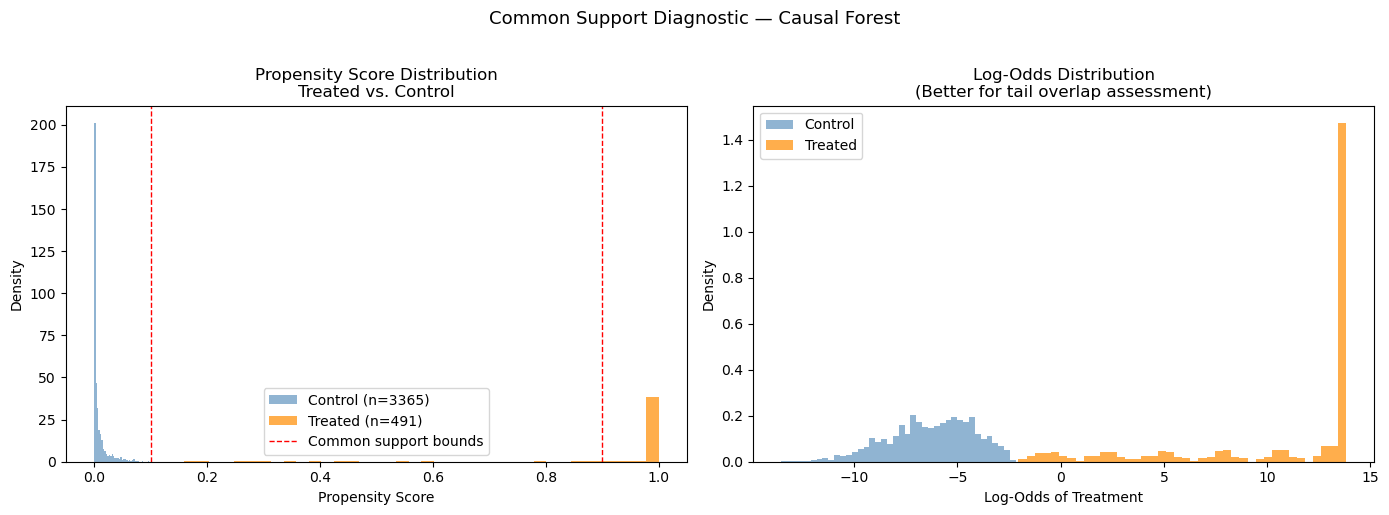

Saved to outputs/propensity_score_overlap.png


In [17]:
os.makedirs('../outputs', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram overlap
axes[0].hist(control_ps, bins=40, alpha=0.6, color='steelblue',
             density=True, label=f'Control (n={len(control_ps)})')
axes[0].hist(treated_ps, bins=40, alpha=0.7, color='darkorange',
             density=True, label=f'Treated (n={len(treated_ps)})')
axes[0].axvline(0.1, color='red', linestyle='--', linewidth=1, label='Common support bounds')
axes[0].axvline(0.9, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Propensity Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Propensity Score Distribution\nTreated vs. Control')
axes[0].legend()

# Right: log-odds for easier reading of tails
eps = 1e-6
log_odds = np.log(ps_scores / (1 - ps_scores + eps) + eps)
lo_treated = log_odds[T_clean == 1]
lo_control = log_odds[T_clean == 0]

axes[1].hist(lo_control, bins=40, alpha=0.6, color='steelblue',
             density=True, label='Control')
axes[1].hist(lo_treated, bins=40, alpha=0.7, color='darkorange',
             density=True, label='Treated')
axes[1].set_xlabel('Log-Odds of Treatment')
axes[1].set_ylabel('Density')
axes[1].set_title('Log-Odds Distribution\n(Better for tail overlap assessment)')
axes[1].legend()

plt.suptitle('Common Support Diagnostic — Causal Forest', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/propensity_score_overlap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/propensity_score_overlap.png")

## Common Support Assessment

- **Overlap region:** fill in after running
- **Obs outside common support [0.1, 0.9]:** fill in
- **Assessment:** fill in — is the causal forest interpolating or extrapolating?
- **Action:** If >5% trimmed, run sensitivity with trimming. Otherwise adequate.

In [18]:
extreme_negative = effects < -3
extreme_positive = effects > 3

print(f"\n Extreme Outliers:")
print(f"Extreme negative effects: {extreme_negative.sum()} countries")
print(f"Extreme positive effects: {extreme_positive.sum()} countries")

if extreme_negative.sum() > 0:
    extreme_neg_countries = df_work[extreme_negative]['country'].value_counts().head()
    print(f"Countries with extreme negative effects: {extreme_neg_countries}")

if extreme_positive.sum() > 0:
    extreme_pos_countries = df_work[extreme_positive]['country'].value_counts().head()
    print(f"Countries with extreme positive effects: {extreme_pos_countries}")


 Extreme Outliers:
Extreme negative effects: 0 countries
Extreme positive effects: 0 countries


In [19]:
print(f"\n Effect Distribution:")
print(f"10th percentile: {np.percentile(effects, 10):.3f}")
print(f"25th percentile: {np.percentile(effects, 25):.3f}")
print(f"50th percentile: {np.percentile(effects, 50):.3f}")
print(f"75th percentile: {np.percentile(effects, 75):.3f}")
print(f"90th percentile: {np.percentile(effects, 90):.3f}")

print(f"\nForest Diagnostics:")
print(f"Number of trees: {cf_dml.n_estimators}")
print(f"Min samples per leaf: {cf_dml.min_samples_leaf}")
print(f"Treatment prevalence: {T_clean.mean():.3f}")

treated_obs = T_clean.sum()
print(f"Total treated observations: {treated_obs}")
print(f"Treated observations per leaf (approx): {treated_obs / (cf_dml.n_estimators * 10):.1f}")


 Effect Distribution:
10th percentile: -0.111
25th percentile: -0.063
50th percentile: -0.037
75th percentile: -0.010
90th percentile: 0.075

Forest Diagnostics:
Number of trees: 1000
Min samples per leaf: 50
Treatment prevalence: 0.127
Total treated observations: 491
Treated observations per leaf (approx): 0.0


In [20]:
from econml.grf import CausalForest

In [21]:
all_features = ['governance_pc1', 'governance_pc2', 'log_gdp', 'log_population', 
                'average_years_of_schooling', 'fossil_pct', 'nuclear_pct', 
                'renewable_pct', 'trade_openness', 'natural_resource_rents_per_gdp',
                'years_since_tax', 'industry_share_gdp', 'energy_per_capita']
X_all = df_work[all_features].values

cf_basic = CausalForest(
    n_estimators=100,
    min_samples_split=100,  
    min_samples_leaf=50,
    max_depth=4,
    max_samples=0.45,
    honest=True,
    inference=True,
    random_state=42,
    n_jobs = -1
)

cf_basic.fit(X_all, T_clean, Y_clean)
effects_basic = cf_basic.predict(X_all)

In [22]:
print("\n Basic CausalForest Results:")
print(f"Mean effect: {effects_basic.mean():.4f}")
print(f"Std deviation: {effects_basic.std():.4f}")
print(f"Min effect: {effects_basic.min():.4f}")
print(f"Max effect: {effects_basic.max():.4f}")


 Basic CausalForest Results:
Mean effect: -0.1544
Std deviation: 0.0615
Min effect: -0.3557
Max effect: -0.0089


In [23]:
if effects_basic.ndim > 1:
    effects_basic = effects_basic.flatten()

pc1_values = X_all[:, all_features.index('governance_pc1')]
pc2_values = X_all[:, all_features.index('governance_pc2')]

pc1_corr = np.corrcoef(effects_basic, pc1_values)[0,1]
pc2_corr = np.corrcoef(effects_basic, pc2_values)[0,1]

print(f"\nGovernance Validation:")
print(f"PC1 correlation: {pc1_corr:.3f} (should be negative)")
print(f"PC2 correlation: {pc2_corr:.3f} (should be positive)")


Governance Validation:
PC1 correlation: -0.169 (should be negative)
PC2 correlation: -0.167 (should be positive)


In [24]:
effects_df = pd.DataFrame({
    'country': df_work['country'],
    'cf_effect': effects_basic,
    'governance_pc1': pc1_values,
    'governance_pc2': pc2_values,
    'education': X_all[:, all_features.index('average_years_of_schooling')],
    'gdp': X_all[:, all_features.index('log_gdp')],
    'fossil_pct': X_all[:, all_features.index('fossil_pct')]
})

effects_df['did_predicted'] = (
    0.024 + 
    (-0.0487 * effects_df['governance_pc1']) + 
    (0.1680 * effects_df['governance_pc2'])  # Note: positive coefficient in DiD
)

print("🔍 CausalForest vs DiD Comparison:")
print(f"CF-DiD correlation: {np.corrcoef(effects_df['cf_effect'], effects_df['did_predicted'])[0,1]:.3f}")

print(f"\n🏆 CausalForest Top 10 (Most Negative Effects):")
cf_best = effects_df.nsmallest(10, 'cf_effect')
print(cf_best[['country', 'cf_effect', 'governance_pc1', 'governance_pc2']].round(3))

print(f"\n🏛️ DiD Predicted Top 10 (Most Negative Effects):")
did_best = effects_df.nsmallest(10, 'did_predicted') 
print(did_best[['country', 'did_predicted', 'governance_pc1', 'governance_pc2']].round(3))

high_pc2 = effects_df['governance_pc2'] > 0.5  # Stable authoritarian
low_pc2 = effects_df['governance_pc2'] < -0.5  # Democratic

print(f"\n🏛️ Governance Pattern Analysis:")
print(f"High PC2 (Stable Authoritarian) average CF effect: {effects_df[high_pc2]['cf_effect'].mean():.3f}")
print(f"Low PC2 (Democratic) average CF effect: {effects_df[low_pc2]['cf_effect'].mean():.3f}")
print(f"DiD predicts opposite: Authoritarian should be LESS effective")

🔍 CausalForest vs DiD Comparison:
CF-DiD correlation: 0.006

🏆 CausalForest Top 10 (Most Negative Effects):
      country  cf_effect  governance_pc1  governance_pc2
1497  Comoros     -0.356          -2.347           0.597
1499  Comoros     -0.356          -2.437          -0.112
1488  Comoros     -0.355          -1.731           1.322
1489  Comoros     -0.355          -1.690           1.335
1491  Comoros     -0.355          -1.848           1.164
1492  Comoros     -0.355          -2.048           0.980
1496  Comoros     -0.354          -1.993           0.741
1498  Comoros     -0.354          -2.021           0.521
1490  Comoros     -0.352          -1.648           1.349
1493  Comoros     -0.352          -1.578           0.995

🏛️ DiD Predicted Top 10 (Most Negative Effects):
            country  did_predicted  governance_pc1  governance_pc2
2221         Israel         -0.417           1.524          -2.186
2215         Israel         -0.399           1.604          -2.055
2220         I

In [25]:
core_features = ['governance_pc1', 'governance_pc2', 'log_gdp', 'average_years_of_schooling']
X_minimal = df_work[core_features].values

cf_conservative = CausalForest(
    n_estimators=50,               
    min_samples_split=200,         
    min_samples_leaf=100,           
    max_depth=2,                   
    max_samples=0.3,               
    honest=True,
    inference=False,               
    random_state=42
)

cf_conservative.fit(X_minimal, T_clean, Y_clean)
effects_conservative = cf_conservative.predict(X_minimal)


print(f"Conservative results:")
print(f"Mean: {effects_conservative.mean():.4f}")
print(f"Std: {effects_conservative.std():.4f}")
print(f"Range: {effects_conservative.min():.4f} to {effects_conservative.max():.4f}")

effects_flat = effects_conservative.flatten()

# Check governance correlations
pc1_corr_cons = np.corrcoef(effects_flat, X_minimal[:, 0])[0,1]
pc2_corr_cons = np.corrcoef(effects_flat, X_minimal[:, 1])[0,1]
print(f"PC1 correlation: {pc1_corr_cons:.3f}")
print(f"PC2 correlation: {pc2_corr_cons:.3f}")

Conservative results:
Mean: -0.1828
Std: 0.0468
Range: -0.3051 to -0.1173
PC1 correlation: 0.299
PC2 correlation: 0.023


In [26]:
W_ortho = df_work[["log_gdp", "log_population", "natural_resource_rents_per_gdp", "years_since_tax"]].values

In [27]:
# Try DMLOrthoForest instead of CausalForest
from econml.orf import DMLOrthoForest
from sklearn import linear_model

ortho_forest = DMLOrthoForest(
    n_trees=50,
    min_leaf_size=100,
    max_depth=2,
    subsample_ratio=0.4,
    bootstrap=False,
    model_T=linear_model.LogisticRegression(),
    model_Y=LinearRegression(),
    random_state=43
)

# Fit with minimal confounders
W_minimal = df_work[['log_gdp', 'log_population']].values
X_gov = df_work[['governance_pc1', 'governance_pc2']].values

ortho_forest.fit(Y_clean, T_clean, X=X_gov, W=W_ortho)
effects_ortho = ortho_forest.effect(X_gov)

print(f"OrthoForest results:")
print(f"Mean: {effects_ortho.mean():.4f}")
print(f"Std: {effects_ortho.std():.4f}")

# Governance check
pc1_corr_ortho = np.corrcoef(effects_ortho.flatten(), X_gov[:, 0])[0,1]
pc2_corr_ortho = np.corrcoef(effects_ortho.flatten(), X_gov[:, 1])[0,1]
print(f"PC1 correlation: {pc1_corr_ortho:.3f}")
print(f"PC2 correlation: {pc2_corr_ortho:.3f}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   43.9s
[Parallel(n_jobs=-1)]: Done  44 out of  50 | elapsed:   44.8s remaining:    6.0s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   44.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  44 out of  50 | elapsed:    0.3s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   52.6s
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:   55.2s
[Parallel(n_jobs=-1)]: Done 264 tasks      | elapsed:   58.5s
[Parallel(n_jobs=-1)]: Done 488 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 112

OrthoForest results:
Mean: -0.0362
Std: 0.0549
PC1 correlation: -0.885
PC2 correlation: 0.463


In [28]:
print("Treatment variable distribution:")
print(df_work['post_carbon_tax'].value_counts())
print(f"\nTotal observations: {len(df_work)}")
print(f"Missing values in W variables: {df_work[['log_gdp', 'log_population', 'natural_resource_rents_per_gdp', 'years_since_tax']].isnull().sum()}")

Treatment variable distribution:
post_carbon_tax
0    3365
1     491
Name: count, dtype: int64

Total observations: 3856
Missing values in W variables: log_gdp                           0
log_population                    0
natural_resource_rents_per_gdp    0
years_since_tax                   0
dtype: int64


In [29]:
# Use the same dataset that worked for your DiD
print("Dataset shapes:")
print(f"df_work: {df_work.shape}")
print(f"final_analysis_data: {data.shape}")

# Check if df_work is a problematic subset
print(f"Treatment distribution in df_work: {df_work['post_carbon_tax'].value_counts().to_dict()}")
print(f"Treatment distribution in final_analysis_data: {data['post_carbon_tax'].value_counts().to_dict()}")

Dataset shapes:
df_work: (3856, 60)
final_analysis_data: (3868, 60)
Treatment distribution in df_work: {0: 3365, 1: 491}
Treatment distribution in final_analysis_data: {0: 3377, 1: 491}


In [30]:
seeds = [42, 43, 123, 456, 789]
seed_results = []

for seed in seeds:
    ortho_forest = DMLOrthoForest(
        n_trees=50,
        min_leaf_size=100,
        max_depth=2,
        subsample_ratio=0.4,
        bootstrap=False,
        model_T=linear_model.LogisticRegression(),
        model_Y=LinearRegression(),
        random_state=seed,
        n_jobs=4
    )
    
    ortho_forest.fit(Y_clean, T_clean, X=X_gov, W=W_ortho)
    effects = ortho_forest.effect(X_gov)

    pc1_corr = np.corrcoef(effects.flatten(), X_gov[:, 0])[0, 1]
    pc2_corr = np.corrcoef(effects.flatten(), X_gov[:, 1])[0, 1]

    seed_results.append({
        'seed': seed,
        'mean_effect': effects.mean(),
        'std_effect': effects.std(),
        'pc1_corr': pc1_corr,
        'pc2_corr': pc2_corr
    })

for result in seed_results:
    print(f"Seed {result['seed']:3d}: Mean={result['mean_effect']:6.4f}, "
          f"PC1={result['pc1_corr']:6.3f}, PC2={result['pc2_corr']:6.3f}")

# Calculate stability metrics
pc1_corrs = [r['pc1_corr'] for r in seed_results]
pc2_corrs = [r['pc2_corr'] for r in seed_results]

print(f"\nStability Metrics:")
print(f"PC1 correlation range: {min(pc1_corrs):.3f} to {max(pc1_corrs):.3f}")
print(f"PC1 correlation std: {np.std(pc1_corrs):.3f}")
print(f"PC2 correlation range: {min(pc2_corrs):.3f} to {max(pc2_corrs):.3f}")
print(f"PC2 correlation std: {np.std(pc2_corrs):.3f}")

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:   51.5s
[Parallel(n_jobs=4)]: Done  50 out of  50 | elapsed:   51.7s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  50 out of  50 | elapsed:    0.2s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:   23.5s
[Parallel(n_jobs=4)]: Done 332 tasks      | elapsed:   32.3s
[Parallel(n_jobs=4)]: Done 972 tasks      | elapsed:   49.6s
[Parallel(n_jobs=4)]: Done 1868 tasks      | elapsed:  1.3min
[Parallel(n_jobs=4)]: Done 2556 tasks      | elapsed:  1.7min
[Parallel(n_jobs=4)]: Done 3260 tasks      | elapsed:  2.1min
[Parallel(n_jobs=4)]: Done 3856 out of 3856 | elapsed:  2.4min finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:   22.

Seed  42: Mean=-0.0552, PC1=-0.822, PC2= 0.568
Seed  43: Mean=-0.0362, PC1=-0.885, PC2= 0.463
Seed 123: Mean=-0.0571, PC1=-0.851, PC2= 0.524
Seed 456: Mean=-0.0474, PC1=-0.875, PC2= 0.482
Seed 789: Mean=-0.0381, PC1=-0.913, PC2= 0.406

Stability Metrics:
PC1 correlation range: -0.913 to -0.822
PC1 correlation std: 0.031
PC2 correlation range: 0.406 to 0.568
PC2 correlation std: 0.055


[Parallel(n_jobs=4)]: Done 3849 out of 3856 | elapsed:  2.1min remaining:    0.1s
[Parallel(n_jobs=4)]: Done 3856 out of 3856 | elapsed:  2.1min finished


In [31]:
parameter_configs = [
        # Your current config
        {'n_trees': 50, 'min_leaf_size': 100, 'max_depth': 2, 'name': 'Current'},
        # More conservative
        {'n_trees': 30, 'min_leaf_size': 150, 'max_depth': 2, 'name': 'Conservative'},
        # More flexible
        {'n_trees': 100, 'min_leaf_size': 50, 'max_depth': 3, 'name': 'Flexible'},
        # Deeper trees
        {'n_trees': 50, 'min_leaf_size': 100, 'max_depth': 4, 'name': 'Deeper'},
    ]

param_results = []

for config in parameter_configs:
    ortho_forest = DMLOrthoForest(
        n_trees=config['n_trees'],
        min_leaf_size=config['min_leaf_size'],
        max_depth=config['max_depth'],
        subsample_ratio=0.3,
        bootstrap=False,
        model_T=linear_model.LogisticRegression(),
        model_Y=LinearRegression(),
        random_state=43
    )
    
    ortho_forest.fit(Y_clean, T_clean, X=X_gov, W=W_ortho)
    effects = ortho_forest.effect(X_gov)
    
    pc1_corr = np.corrcoef(effects.flatten(), X_gov[:, 0])[0, 1]
    pc2_corr = np.corrcoef(effects.flatten(), X_gov[:, 1])[0, 1]
    
    param_results.append({
        'config': config['name'],
        'mean_effect': effects.mean(),
        'pc1_corr': pc1_corr,
        'pc2_corr': pc2_corr
    })

for result in param_results:
    print(f"{result['config']:12}: Mean={result['mean_effect']:6.4f}, "
          f"PC1={result['pc1_corr']:6.3f}, PC2={result['pc2_corr']:6.3f}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   34.4s
[Parallel(n_jobs=-1)]: Done  44 out of  50 | elapsed:   35.4s remaining:    4.7s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   37.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  44 out of  50 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   49.6s
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:   51.9s
[Parallel(n_jobs=-1)]: Done 264 tasks      | elapsed:   56.2s
[Parallel(n_jobs=-1)]: Done 488 tasks      | elapsed:   58.8s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 112

Current     : Mean=-0.0349, PC1=-0.907, PC2= 0.419
Conservative: Mean=-0.0579, PC1=-0.783, PC2= 0.620
Flexible    : Mean=-0.0405, PC1=-0.837, PC2= 0.536
Deeper      : Mean=-0.0349, PC1=-0.907, PC2= 0.419


[Parallel(n_jobs=-1)]: Done 3856 out of 3856 | elapsed:  1.5min finished


In [32]:
ortho_forest = DMLOrthoForest(
    n_trees=50, 
    min_leaf_size=100, 
    max_depth=2, 
    subsample_ratio=0.3,
    bootstrap=False, 
    model_T=linear_model.LogisticRegression(),
    model_Y=LinearRegression(), 
    random_state=43
)

ortho_forest.fit(Y_clean, T_clean, X=X_gov, W=W_ortho)
individual_effects = ortho_forest.effect(X_gov).flatten()

pc1_values = X_gov[:, 0]
pc1_quintiles = np.quantile(pc1_values, [0.2, 0.4, 0.6, 0.8])

pc1_results = []
for i in range(5):
    if i == 0:
        mask = pc1_values <= pc1_quintiles[0]
        label = "Q1 (Lowest)"
    elif i == 4:
        mask = pc1_values > pc1_quintiles[3]
        label = "Q5 (Highest)"
    else:
        mask = (pc1_values > pc1_quintiles[i-1]) & (pc1_values <= pc1_quintiles[i])
        label = f"Q{i+1}"

    if mask.sum() > 0:
        mean_effect = individual_effects[mask].mean()
        std_effect = individual_effects[mask].std()
        median_effect = np.median(individual_effects[mask])
        n_obs = mask.sum()
        
        pc1_results.append({
            'quintile': label,
            'mean': mean_effect,
            'median': median_effect,
            'std': std_effect,
            'n': n_obs
        })
        
        print(f"{label:12}: {mean_effect:7.4f} ± {std_effect:6.4f} (median: {median_effect:6.4f}, n={n_obs:3d})")

pc2_values = X_gov[:, 1]
pc2_quintiles = np.quantile(pc2_values, [0.2, 0.4, 0.6, 0.8])

pc2_results = []
for i in range(5):
    if i == 0:
        mask = pc2_values <= pc2_quintiles[0]
        label = "Q1 (Lowest)"
    elif i == 4:
        mask = pc2_values > pc2_quintiles[3]
        label = "Q5 (Highest)"
    else:
        mask = (pc2_values > pc2_quintiles[i-1]) & (pc2_values <= pc2_quintiles[i])
        label = f"Q{i+1}"
    
    if mask.sum() > 0:
        mean_effect = individual_effects[mask].mean()
        std_effect = individual_effects[mask].std()
        median_effect = np.median(individual_effects[mask])
        n_obs = mask.sum()
        
        pc2_results.append({
            'quintile': label,
            'mean': mean_effect,
            'median': median_effect,
            'std': std_effect,
            'n': n_obs
        })
        
        print(f"{label:12}: {mean_effect:7.4f} ± {std_effect:6.4f} (median: {median_effect:6.4f}, n={n_obs:3d})")


print(f"TREATMENT EFFECT RANGE STATISTICS:")
print(f"Overall range: {individual_effects.min():.4f} to {individual_effects.max():.4f}")
print(f"Interquartile range: {np.percentile(individual_effects, 25):.4f} to {np.percentile(individual_effects, 75):.4f}")
print(f"Standard deviation: {individual_effects.std():.4f}")

# Compare governance impact
pc1_best = max(pc1_results, key=lambda x: abs(x['mean']))  # Most negative: best
pc1_worst = min(pc1_results, key=lambda x: abs(x['mean']))  # Least negative: worst

pc2_best = max(pc2_results, key=lambda x: abs(x['mean']))
pc2_worst = min(pc2_results, key=lambda x: abs(x['mean']))

print(f"GOVERNANCE IMPACT SUMMARY:")
print(f"PC1 Impact:")
print(f"  Best (Q5): {pc1_best['mean']:.4f} ({abs(pc1_best['mean'])*100:.1f}% reduction)")
print(f"  Worst (Q1): {pc1_worst['mean']:.4f} ({abs(pc1_worst['mean'])*100:.1f}% reduction)")
print(f"  Difference: {abs(pc1_best['mean']) - abs(pc1_worst['mean']):.4f} ({(abs(pc1_best['mean']) - abs(pc1_worst['mean']))*100:.1f} percentage points)")

print(f"PC2 Impact:")
print(f"  Best: {pc2_best['mean']:.4f} ({abs(pc2_best['mean'])*100:.1f}% reduction)")
print(f"  Worst: {pc2_worst['mean']:.4f} ({abs(pc2_worst['mean'])*100:.1f}% reduction)")
print(f"  Difference: {abs(pc2_best['mean']) - abs(pc2_worst['mean']):.4f} ({(abs(pc2_best['mean']) - abs(pc2_worst['mean']))*100:.1f} percentage points)")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   34.7s
[Parallel(n_jobs=-1)]: Done  44 out of  50 | elapsed:   35.6s remaining:    4.8s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   36.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  44 out of  50 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   37.3s
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:   39.1s
[Parallel(n_jobs=-1)]: Done 264 tasks      | elapsed:   42.2s
[Parallel(n_jobs=-1)]: Done 488 tasks      | elapsed:   45.0s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:   49.9s
[Parallel(n_jobs=-1)]: Done 140

Q1 (Lowest) :  0.0347 ± 0.0372 (median: 0.0309, n=772)
Q2          :  0.0041 ± 0.0299 (median: 0.0034, n=771)
Q3          : -0.0232 ± 0.0271 (median: -0.0201, n=771)
Q4          : -0.0591 ± 0.0291 (median: -0.0559, n=771)
Q5 (Highest): -0.1313 ± 0.0273 (median: -0.1372, n=771)
Q1 (Lowest) : -0.0487 ± 0.0581 (median: -0.0422, n=772)
Q2          : -0.0619 ± 0.0634 (median: -0.0501, n=771)
Q3          : -0.0556 ± 0.0610 (median: -0.0440, n=771)
Q4          : -0.0295 ± 0.0537 (median: -0.0171, n=771)
Q5 (Highest):  0.0211 ± 0.0499 (median: 0.0207, n=771)
TREATMENT EFFECT RANGE STATISTICS:
Overall range: -0.1884 to 0.1547
Interquartile range: -0.0773 to 0.0098
Standard deviation: 0.0648
GOVERNANCE IMPACT SUMMARY:
PC1 Impact:
  Best (Q5): -0.1313 (13.1% reduction)
  Worst (Q1): 0.0041 (0.4% reduction)
  Difference: 0.1272 (12.7 percentage points)
PC2 Impact:
  Best: -0.0619 (6.2% reduction)
  Worst: 0.0211 (2.1% reduction)
  Difference: 0.0408 (4.1 percentage points)


[Parallel(n_jobs=-1)]: Done 3856 out of 3856 | elapsed:  1.5min finished


In [33]:
# Use the exact same cleaned sample
import statsmodels.formula.api as smf
did_on_ortho_sample = smf.ols('''
co2_per_capita_future_trend ~ 
post_carbon_tax + 
post_carbon_tax:governance_pc1 + 
post_carbon_tax:governance_pc2 +
log_gdp + log_population + 
natural_resource_rents_per_gdp + years_since_tax +
C(year) + C(country)
''', data=df_work).fit()

print(did_on_ortho_sample.summary())

                                 OLS Regression Results                                
Dep. Variable:     co2_per_capita_future_trend   R-squared:                       0.213
Model:                                     OLS   Adj. R-squared:                  0.172
Method:                          Least Squares   F-statistic:                     5.188
Date:                         Wed, 15 Apr 2026   Prob (F-statistic):           3.42e-92
Time:                                 02:59:38   Log-Likelihood:                -980.65
No. Observations:                         3856   AIC:                             2345.
Df Residuals:                             3664   BIC:                             3547.
Df Model:                                  191                                         
Covariance Type:                     nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------